In [33]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from scipy import stats

In [60]:
# On veut une fct tel que: y = B_0 + B_1 * x
PATH = Path("~/Documents/Coding/linear_regression/")
df = pd.read_csv(PATH / "fr_gov_yield.csv")
labels = ["3M", "6M", "1Y", "2Y", "3Y", "4Y", "5Y", "6Y", "7Y", "8Y", "9Y", "10Y", "15Y", "20Y", "30Y", "50Y"]
df["label"] = labels

print(df.iloc[:, [0]])

    maturity
0       0.25
1       0.50
2       1.00
3       2.00
4       3.00
5       4.00
6       5.00
7       6.00
8       7.00
9       8.00
10      9.00
11     10.00
12     15.00
13     20.00
14     30.00
15     50.00


In [54]:
def load_curve_yield(path:str) -> pd.DataFrame:
    """
    Load the dataframe with the correct formating for applying our linear regression
    In the following case, since we're looking to predict our yield over time, we need to retrieve the necessary criteria.
    Inputs:
    data = our database
    x = maturities (in integer format)
    y = yield rate (in %)
    (optional) label = String names related to the maturities

    Output -> DataFrame
    """
    try:
        data = pd.read_csv(path)
        X = data.iloc[[0], :]
        y = data.iloc[:, [0]]
        return pd.DataFrame(data), X, y

    except ValueError:
        print("The dataset is expected to be in csv format")
        return None
        
def apply_linear_regression(df: pd.DataFrame):
    """
    Implementation of the linear regression using sklearn library.
    This function aims to forecast our yield rate and compute the residuals.
    Inputs:
    X = maturities (int)
    y = yield rate (in %)
    """
    # Before applying our linear regression models we need to reshape our maturities in order to assure its properly compute both variables.
    try:
        X = load_curve_yield(PATH / "fr_gov_yield.csv")
        X = X.reshape(-1, 1)
        y = load_curve_yield()
        model = LinearRegression()
        model.fit(X, y)
        


SyntaxError: unexpected EOF while parsing (2820714893.py, line 38)

In [52]:
load_curve_yield(PATH / "fr_gov_yield.csv")

,maturity,yield_2024
0,0.25,3.800
1,0.50,3.665
2,1.00,3.205
3,2.00,2.447
4,3.00,2.382
5,4.00,2.357
6,5.00,2.379
7,6.00,2.377
8,7.00,2.433
9,8.00,2.492


In [27]:
x = np.array(df["maturity"]).reshape(-1, 1)
y = np.array(df["yield_2024"])

model = LinearRegression()
model.fit(x, y)

print(f"Intercept (β₀) : {model.intercept_:.4f}")
print(f"Pente    (β₁) : {model.coef_[0]:.4f}")
print(f"R²            : {r2_score(y, model.predict(x)):.4f}")
print(f"MSE           : {mean_squared_error(y, model.predict(x)):.6f}")

# Interprétation : β₁ ≈ 2.7864 signifie que chaque année de maturité supplémentaire
# ajoute ~278.64 points de base au taux

Intercept (β₀) : 2.7864
Pente    (β₁) : 0.0018
R²            : 0.0023
MSE           : 0.211340


In [ ]:
y_predict = model.predict(x)
residus = y - y_predict


  Régression Linéaire — Courbe des Taux US

📊 Données chargées : 16 points de courbe

📈 Métriques :
   R²                   : 0.0023
   MSE                  : 0.2113
   RMSE                 : 0.4597
   RMSE_bps             : 45.9718
   β₀ (intercept)       : 2.7864
   β₁ (pente)           : 0.0018

🔍 Analyse des résidus (en points de base) :
label  taux_observe  taux_predit  residu_bps
   3M         3.800     2.786878  101.312234
   6M         3.665     2.787315   87.768462
   1Y         3.205     2.788191   41.680919
   2Y         2.447     2.789942  -34.294168
   3Y         2.382     2.791693  -40.969255
   4Y         2.357     2.793443  -43.644342
   5Y         2.379     2.795194  -41.619429
   6Y         2.377     2.796945  -41.994516
   7Y         2.433     2.798696  -36.569603
   8Y         2.492     2.800447  -30.844690
   9Y         2.573     2.802198  -22.919777
  10Y         2.662     2.803949  -14.194863
  15Y         2.968     2.812703   15.529702
  20Y         3.123     2.

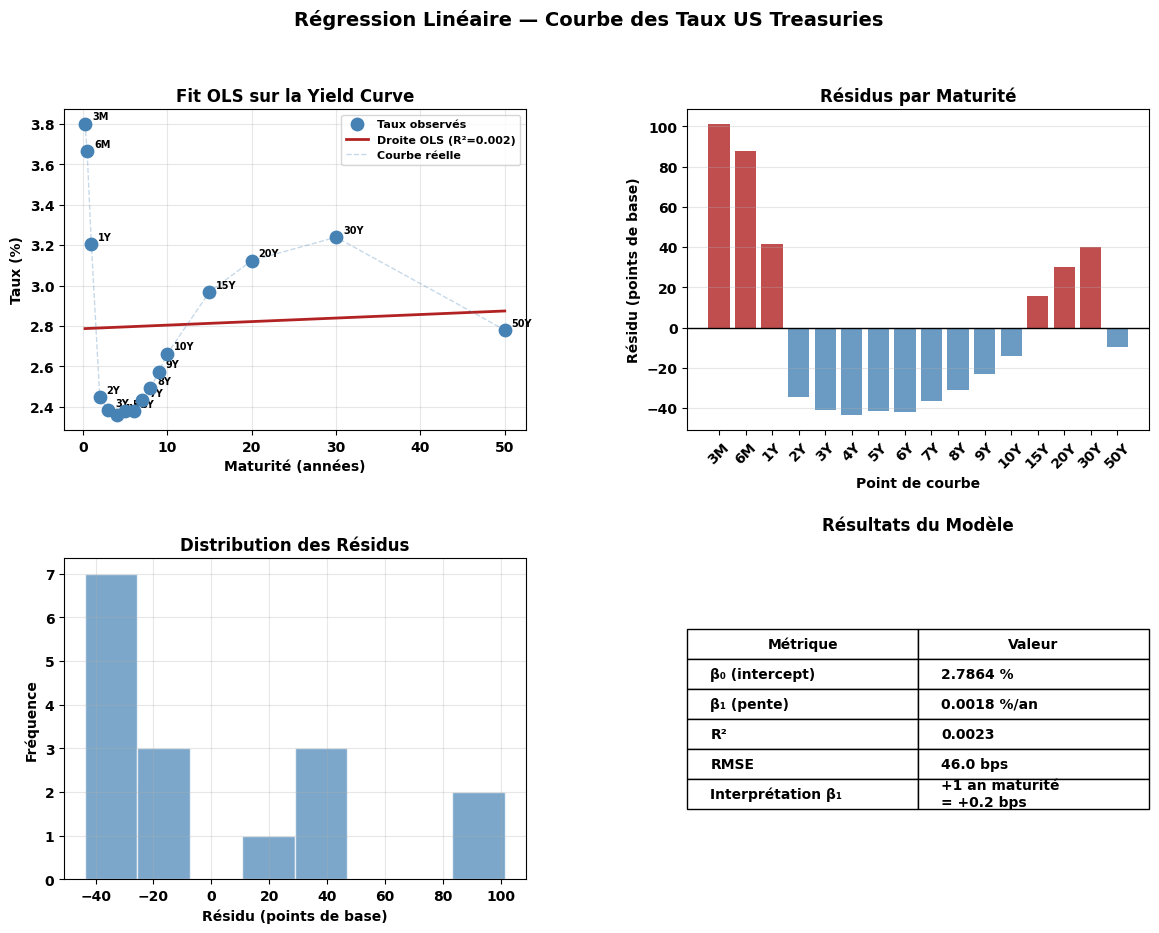

Figure sauvegardée : regression_yield_curve.png


In [62]:
"""
Lab Leçon 1 : Modélisation de la courbe des taux US par régression linéaire
Données : Treasury yields via yfinance ou entrées manuelles
"""


# ─────────────────────────────────────────────
# 2. MODÈLE : Régression linéaire simple
# ─────────────────────────────────────────────

def ajuster_regression(df: pd.DataFrame):
    """
    Ajuste une régression linéaire taux ~ f(maturité).
    
    Note : Une droite est une approximation grossière de la yield curve réelle
    (qui est concave/convexe). Utile pour comprendre OLS, pas pour le trading.
    
    Returns:
        modele, X, y, y_pred
    """
    X = np.array(df["maturity"]).reshape(-1, 1)
    y = np.array(df["yield_2024"])
        
    modele = LinearRegression()
    modele.fit(X, y)
    y_pred = modele.predict(X)
    
    return modele, X, y, y_pred


# ─────────────────────────────────────────────
# 3. DIAGNOSTIC : Analyse des résidus
# ─────────────────────────────────────────────

def analyser_residus(y: np.ndarray, y_pred: np.ndarray, labels: list) -> pd.DataFrame:
    """
    Analyse complète des résidus — étape critique pour valider les hypothèses OLS.
    En finance : les résidus révèlent où le modèle échoue (ex : ventre de courbe).
    """
    residus = y - y_pred
    
    df_residus = pd.DataFrame({
        "label": labels,
        "taux_observe": y,
        "taux_predit": y_pred,
        "residu_bps": residus * 100,  # conversion en points de base
    })
    
    stat, p_value = stats.shapiro(residus)
    df_residus.attrs["shapiro_p"] = p_value
    
    return df_residus


# ─────────────────────────────────────────────
# 4. MÉTRIQUES
# ─────────────────────────────────────────────

def calculer_metriques(y: np.ndarray, y_pred: np.ndarray, modele) -> dict:
    """
    Calcule les métriques de performance du modèle.
    
    R² : proportion de la variance de y expliquée par le modèle
         → 1.0 = parfait, 0.0 = aussi utile que prédire la moyenne, <0 = catastrophique
    RMSE : erreur moyenne en unités originales (ici en % de taux)
    """
    return {
        "R²": r2_score(y, y_pred),
        "MSE": mean_squared_error(y, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
        "RMSE_bps": np.sqrt(mean_squared_error(y, y_pred)) * 100,
        "β₀ (intercept)": modele.intercept_,
        "β₁ (pente)": modele.coef_[0],
    }


# ─────────────────────────────────────────────
# 5. VISUALISATION
# ─────────────────────────────────────────────

def visualiser(df: pd.DataFrame, y_pred: np.ndarray, df_residus: pd.DataFrame, metriques: dict):
    """Génère un dashboard 2x2 : courbe fit + résidus + distribution résidus + métriques."""
    
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle("Régression Linéaire — Courbe des Taux US Treasuries",
                 fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
    
    X = df["maturity"].values
    y = df["yield_2024"].values
    
    # — Plot 1 : Fit de la courbe
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(X, y, color="steelblue", zorder=5, label="Taux observés", s=80)
    ax1.plot(X, y_pred, color="firebrick", linewidth=2, label=f"Droite OLS (R²={metriques['R²']:.3f})")
    ax1.plot(X, y, color="steelblue", alpha=0.3, linewidth=1, linestyle="--", label="Courbe réelle")
    for i, label in enumerate(df["label"]):
        ax1.annotate(label, (X[i], y[i]), textcoords="offset points", xytext=(5, 3), fontsize=7)
    ax1.set_xlabel("Maturité (années)")
    ax1.set_ylabel("Taux (%)")
    ax1.set_title("Fit OLS sur la Yield Curve")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # — Plot 2 : Résidus par point de courbe
    ax2 = fig.add_subplot(gs[0, 1])
    colors = ["firebrick" if r > 0 else "steelblue" for r in df_residus["residu_bps"]]
    ax2.bar(df_residus["label"], df_residus["residu_bps"], color=colors, alpha=0.8)
    ax2.axhline(0, color="black", linewidth=1)
    ax2.set_xlabel("Point de courbe")
    ax2.set_ylabel("Résidu (points de base)")
    ax2.set_title("Résidus par Maturité")
    ax2.tick_params(axis="x", rotation=45)
    ax2.grid(True, alpha=0.3, axis="y")
    
    # — Plot 3 : Distribution des résidus
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.hist(df_residus["residu_bps"], bins=8, color="steelblue", alpha=0.7, edgecolor="white")
    ax3.set_xlabel("Résidu (points de base)")
    ax3.set_ylabel("Fréquence")
    ax3.set_title("Distribution des Résidus")
    ax3.grid(True, alpha=0.3)
    
    # — Plot 4 : Tableau métriques
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis("off")
    rows = [
        ["β₀ (intercept)", f"{metriques['β₀ (intercept)']:.4f} %"],
        ["β₁ (pente)", f"{metriques['β₁ (pente)']:.4f} %/an"],
        ["R²", f"{metriques['R²']:.4f}"],
        ["RMSE", f"{metriques['RMSE_bps']:.1f} bps"],
        ["Interprétation β₁", "+1 an maturité\n= +" + f"{metriques['β₁ (pente)']*100:.1f} bps"],
    ]
    table = ax4.table(cellText=rows, colLabels=["Métrique", "Valeur"],
                      loc="center", cellLoc="left")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)
    ax4.set_title("Résultats du Modèle", pad=20)
    
    plt.savefig("regression_yield_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure sauvegardée : regression_yield_curve.png")


# ─────────────────────────────────────────────
# 6. MAIN — Pipeline complet
# ─────────────────────────────────────────────

def main():
    print("=" * 60)
    print("  Régression Linéaire — Courbe des Taux US")
    print("=" * 60)
    
    print(f"\n📊 Données chargées : {len(df)} points de courbe\n")
    
    modele, X, y, y_pred = ajuster_regression(df)
    
    metriques = calculer_metriques(y, y_pred, modele)
    print("📈 Métriques :")
    for k, v in metriques.items():
        print(f"   {k:20s} : {v:.4f}")
    
    df_residus = analyser_residus(y, y_pred, df["label"].tolist())
    print(f"\n🔍 Analyse des résidus (en points de base) :")
    print(df_residus[["label", "taux_observe", "taux_predit", "residu_bps"]].to_string(index=False))
    print(f"\n   Test de Shapiro-Wilk (normalité résidus) : p = {df_residus.attrs['shapiro_p']:.4f}")
    if df_residus.attrs["shapiro_p"] > 0.05:
        print("   → Résidus compatibles avec une loi normale (p > 0.05)")
    else:
        print("   → Résidus NON normaux (p < 0.05) — hypothèse OLS violée")
    
    b1 = metriques["β₁ (pente)"]
    b0 = metriques["β₀ (intercept)"]
    print(f"\n💡 Interprétation financière :")
    print(f"   Chaque année de maturité supplémentaire ajoute {b1*100:.1f} bps au taux")
    print(f"   Taux estimé à maturité nulle (court terme) : {b0:.2f}%")
    
    maturite_cible = 15
    taux_predit = modele.predict([[maturite_cible]])[0]
    print(f"   Taux prédit à {maturite_cible} ans : {taux_predit:.2f}%")
    
    visualiser(df, y_pred, df_residus, metriques)


if __name__ == "__main__":
    main()

In [99]:
np.random.seed(42)
n = 120

data = {
    "maturite":        np.random.uniform(1, 15, n),
    "rating_score":    np.random.randint(1, 8, n),   # 1=AAA, 7=BBB-
    "dette_ebitda":    np.random.uniform(0.5, 6.0, n),
    "couverture_int":  np.random.uniform(1.5, 12.0, n),
    "taille_emission": np.random.uniform(200, 2000, n),  # en millions EUR
}

# Spread = combinaison linéaire des facteurs + bruit
spread = (
    20
    + 8  * data["maturite"]
    + 18 * data["rating_score"]
    + 12 * data["dette_ebitda"]
    - 6  * data["couverture_int"]
    - 0.02 * data["taille_emission"]
    + np.random.normal(0, 15, n)
)

df = pd.DataFrame(data)
df["spread_bps"] = spread


In [100]:
df.describe()

,maturite,rating_score,dette_ebitda,couverture_int,taille_emission,spread_bps
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,7.679541,3.600000,3.416401,6.678936,1189.656973,121.422950
std,4.169592,2.096015,1.602578,3.124950,568.066115,62.499427
min,1.077310,1.000000,0.527839,1.613795,220.436561,-3.358126
25%,3.772455,2.000000,2.105061,4.120957,704.121838,75.864869
50%,7.762074,3.000000,3.630517,6.676690,1251.173381,119.922068
75%,11.596035,6.000000,4.809852,9.388093,1687.673195,156.225392
max,14.816417,7.000000,5.945296,11.900304,1999.491812,281.351885


In [101]:
df.dtypes

maturite           float64
rating_score         int64
dette_ebitda       float64
couverture_int     float64
taille_emission    float64
spread_bps         float64
dtype: object

In [103]:
for col in df.columns:
    # Compute metrics and relation
    metrics = {
        "mean": df[col].mean(),
        "standard deviation": df[col].std(),
        "variance": df[col].var()
    }
    print(f"Column: {col}")
    print(metrics)
    print()


Column: maturite
{'mean': np.float64(7.679541159894192), 'standard deviation': np.float64(4.169592105276164), 'variance': np.float64(17.38549832438132)}

Column: rating_score
{'mean': np.float64(3.6), 'standard deviation': np.float64(2.0960146256465793), 'variance': np.float64(4.393277310924369)}

Column: dette_ebitda
{'mean': np.float64(3.4164005954339056), 'standard deviation': np.float64(1.602578312387675), 'variance': np.float64(2.5682572473353282)}

Column: couverture_int
{'mean': np.float64(6.6789360942702265), 'standard deviation': np.float64(3.1249500724238306), 'variance': np.float64(9.765312955141704)}

Column: taille_emission
{'mean': np.float64(1189.6569726288644), 'standard deviation': np.float64(568.0661147461179), 'variance': np.float64(322699.11072274967)}

Column: spread_bps
{'mean': np.float64(121.42294950534242), 'standard deviation': np.float64(62.49942686599323), 'variance': np.float64(3906.1783585776366)}



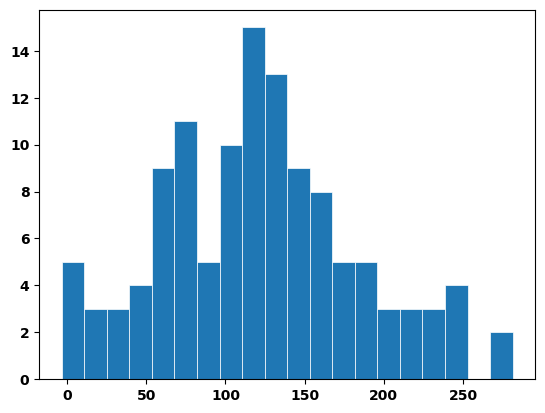

In [109]:
import matplotlib.pyplot as plt

x  = df['spread_bps']

fig, ax = plt.subplots()

ax.hist(x, bins=20, linewidth=0.5, edgecolor="white")
plt.show()

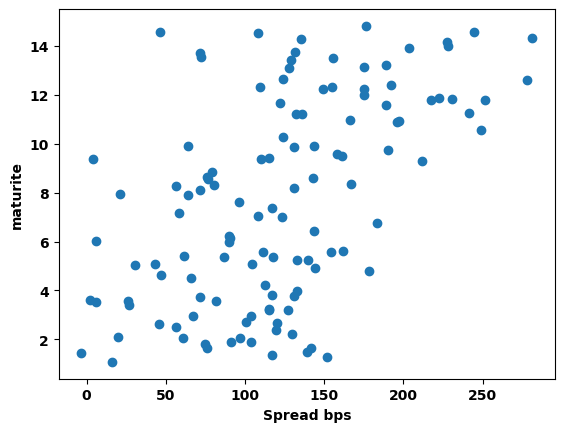

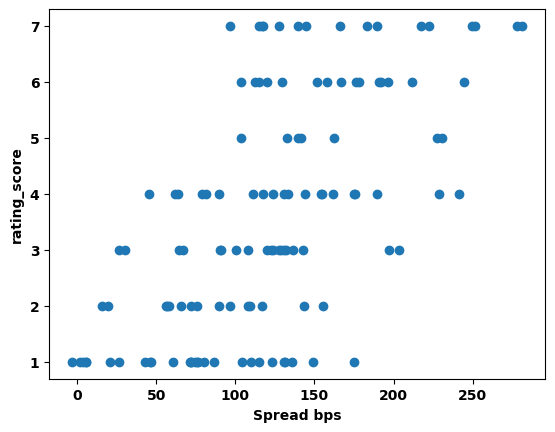

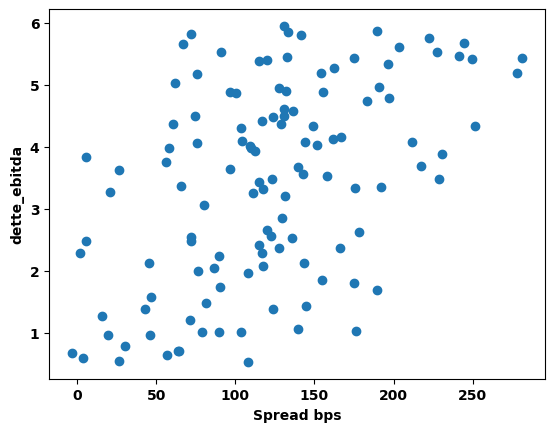

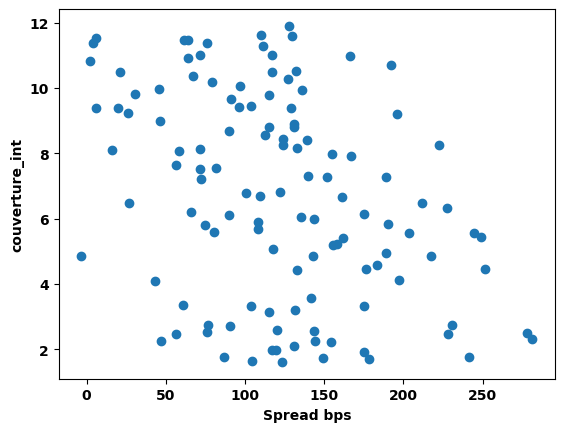

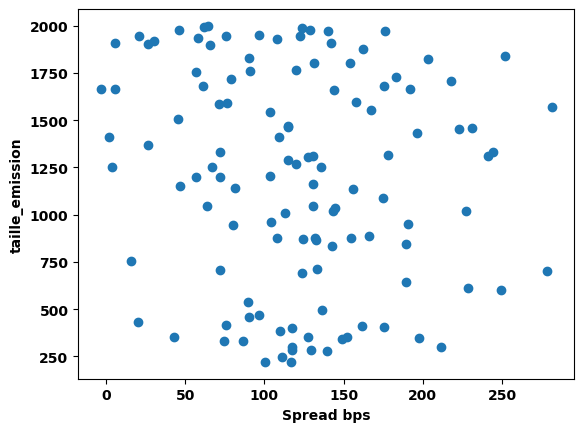

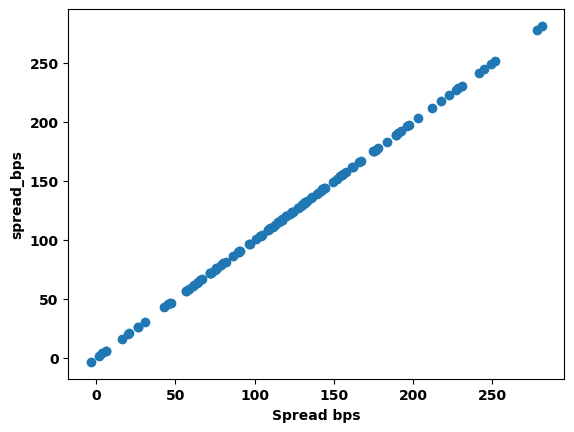

In [126]:
for col in df.columns:
    x = df["spread_bps"]
    y = df[col]

    fig, ax = plt.subplots()
    ax.scatter(x, y)
    plt.xlabel("Spread bps")
    plt.ylabel(col)
    plt.show()

In [ ]:
X = df["spread_bps"].values.reshape(-1, 1)
y = df[col].values
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)



